In [52]:
import pandas as pd
import pyBigWig as pybw
import numpy as np

In [80]:
#bw = pybw.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/572M/572M_wo_bias.bw")
#bwpeaks = pybw.open("/mnt/lab_data2/anusri/chrombpnet/GM12878/GM12878_wo_bias.bw")
bwbg = pybw.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/572M/572M_wo_bias.bw")
bwpeaks = pybw.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/572M/572M_wo_bias.bw")

#bound sites 
# bound_file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/moods/finemo_output/fold0/chr1_hits_unique.tsv"
# bound = pd.read_csv(bound_file, sep='\t', header=None)

bound_file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/moods/finemo_output/fold0/chr1_hits_unique.tsv"
bound = pd.read_csv(bound_file, sep='\t', header=None)

#bound sites 
unbound_file = "/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/moods/fimo_output/unbound_hits.tsv"
unbound = pd.read_csv(unbound_file, sep='\t', header=None)


In [81]:
def get_marginal_footprints(df,bw):
    df = df[(df[1]>557) & (df[2]<248956422)].reset_index()
    num=0
    for i,r in df.iterrows():
        #print(i)
        if i==0:
            value = bw.values(r[0],r[1]-50,r[2]+50)
        else:
            #print(i,value)
            value = np.vstack((value,bw.values(r[0],r[1]-50,r[2]+50)))
        num+=1
        
    num=0   
    for i,r in df.iterrows():
        #print(i)
        if i==0:
            count = np.sum(np.nan_to_num(bw.values(r[0],r[1]-500,r[2]+500)))
        else:
            #print(i,value)
            count += np.sum(np.nan_to_num(bw.values(r[0],r[1]-500,r[2]+500)))
        num+=1
    return np.sum(value, axis=0)/num, count/num

In [82]:
motifs=[]
for i in range(0,26):
    if i in [4,9,11, 20]:
        continue
    if i==1:
        i=4
    motifs.append("GM12878_SIGNAL_metacluster_0_pattern_"+str(i))

In [83]:
len(motifs)

22

In [84]:
motifs_names=["CTCF", "IRF4", "SPI1", "BATF/JUNB", "RUNX3", "RELB", "SP1", "ELK1", "NFYA", "POU2F2", "BATF/IRF4", "NRF1", "ATF3", "SP1/ETS1", "EBF1", "ZN143", "MEF2C", "PAX8", "HNF1B",
             "PAX8/PAX5", "YY1", "ZBTB33"]

In [85]:
len(motifs_names)

22

In [86]:
unbound_footprints = {}

for motif in motifs:
    kmotif=motif.replace("GM12878_SIGNAL_metacluster_0_","")
    footprint_unbound = get_marginal_footprints(unbound[unbound[3]==kmotif].sample(1000), bwbg)
    unbound_footprints[kmotif] = footprint_unbound

In [87]:
bound_footprints = {}

for motif in motifs:
    kmotif=motif.replace("GM12878_SIGNAL_metacluster_0_","")
    df = bound[bound[5]=="pos_patterns."+kmotif]
    print(df.shape)
    #if df.shape[0]>1000:
        #df=df.sample(1000)
    
    footprint_unbound = get_marginal_footprints(df, bwpeaks)
    bound_footprints[kmotif] = footprint_unbound

(3873, 15)
(3828, 15)
(9281, 15)
(8480, 15)
(28714, 15)
(3496, 15)
(11397, 15)
(11640, 15)
(1201, 15)
(1944, 15)
(708, 15)
(3502, 15)
(4989, 15)
(2197, 15)
(2942, 15)
(224, 15)
(1339, 15)
(248, 15)
(458, 15)
(2272, 15)
(426, 15)
(6338, 15)


In [88]:
main="/mnt/lab_data2/anusri/chrombpnet/"
import deepdish
mfile=main+"results/chrombpnet/ATAC_PE/GM12878/nautilus_runs/GM12878_03.01.2022_bias_128_4_1234_0.4_fold_0/chrombpnet_model/all_motifs_footprints_fwd/motif_footprints.h5"
mdata = deepdish.io.load(mfile)

In [89]:
marginal_footprints = {}
marginal_footprints_counts = {}
for motif in motifs:
    kmotif=motif.replace("GM12878_SIGNAL_metacluster_0_","")
    marginal_footprints[kmotif] = mdata[motif][0]
    marginal_footprints_counts[kmotif] = mdata[motif][1]

In [90]:
observed = pybw.open(main+ "results/chrombpnet/ATAC_PE/GM12878/data/GM12878_unstranded.bw")

In [91]:
peak_bed = pd.read_csv(main+ "results/chrombpnet/ATAC_PE/GM12878/data/peaks_no_blacklist.bed", sep='\t', header=None)
peak_bed = peak_bed.sample(1000)
peak_counts_pred = []
for i,r in peak_bed.iterrows():
    val = np.nan_to_num(observed.values(r[0], r[1]+r[9]-500, r[1]+r[9]+500))
    peak_counts_pred.append(np.log(sum(val)+1))

In [92]:
nonpeak_bed = pd.read_csv(main+ "results/chrombpnet/ATAC_PE/GM12878/negatives_data/negatives_with_summit.bed", sep='\t', header=None)
nonpeak_bed = nonpeak_bed.sample(1000)
nonpeak_counts_pred = []
for i,r in nonpeak_bed.iterrows():
    val = np.nan_to_num(observed.values(r[0], r[1]+r[9]-500, r[1]+r[9]+500))
    nonpeak_counts_pred.append(np.log(sum(val)+1))

In [93]:
#peak_counts_pred = 

In [94]:
#peak_counts_pred

In [95]:
marginal_footprints_counts[kmotif]

array([510.0764], dtype=float32)

In [133]:
def plot_histogram(values, bg_values, line_value, control_line1, control_line, line_title, ax):
    # Plot histogram
    #plt.figure(figsize=(10, 6))
    ax.hist(values, bins=50, color='#ECA28D', density=True, label="peak")
    ax.hist(bg_values, bins=50, color='#95D1CF', density=True, label="bg")

    # Add vertical line
    ax.axvline(control_line1, color='green', linestyle='dashed', linewidth=2)
    ax.text(control_line1, plt.ylim()[1]*0.9, "", color='green', fontsize=12, ha='center', va='bottom')

    # Add vertical line
    ax.axvline(control_line, color='black', linestyle='dashed', linewidth=2)
    ax.text(control_line, plt.ylim()[1]*0.9, "", color='black', fontsize=12, ha='center', va='bottom')

    ax.axvline(line_value, color='red', linestyle='dashed', linewidth=2)
    # Add text for the line title
    ax.text(line_value, plt.ylim()[1]*0.9, '', color='red', fontsize=12, ha='center', va='bottom')
    ax.legend()
    # Add title and labels
#     plt.title('Histogram of Values in Chromosome 1')
#     plt.xlabel('Value')
#     plt.ylabel('Frequency')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Show plot
#    plt.show()

In [134]:
#motif

In [135]:
#motifs[0]

In [136]:
#motifs_names[0]

In [137]:
#motifs

In [138]:
# index=7
# plot_histogram(peak_counts_pred, nonpeak_counts_pred, np.log(mdata[motifs[index]][1]), motifs_names[index])

GM12878_SIGNAL_metacluster_0_pattern_0
GM12878_SIGNAL_metacluster_0_pattern_4
GM12878_SIGNAL_metacluster_0_pattern_2
GM12878_SIGNAL_metacluster_0_pattern_3
GM12878_SIGNAL_metacluster_0_pattern_5
GM12878_SIGNAL_metacluster_0_pattern_6
GM12878_SIGNAL_metacluster_0_pattern_7
GM12878_SIGNAL_metacluster_0_pattern_8
GM12878_SIGNAL_metacluster_0_pattern_10
GM12878_SIGNAL_metacluster_0_pattern_12
GM12878_SIGNAL_metacluster_0_pattern_13
GM12878_SIGNAL_metacluster_0_pattern_14
GM12878_SIGNAL_metacluster_0_pattern_15
GM12878_SIGNAL_metacluster_0_pattern_16
GM12878_SIGNAL_metacluster_0_pattern_17
GM12878_SIGNAL_metacluster_0_pattern_18
GM12878_SIGNAL_metacluster_0_pattern_19
GM12878_SIGNAL_metacluster_0_pattern_21
GM12878_SIGNAL_metacluster_0_pattern_22
GM12878_SIGNAL_metacluster_0_pattern_23
GM12878_SIGNAL_metacluster_0_pattern_24
GM12878_SIGNAL_metacluster_0_pattern_25


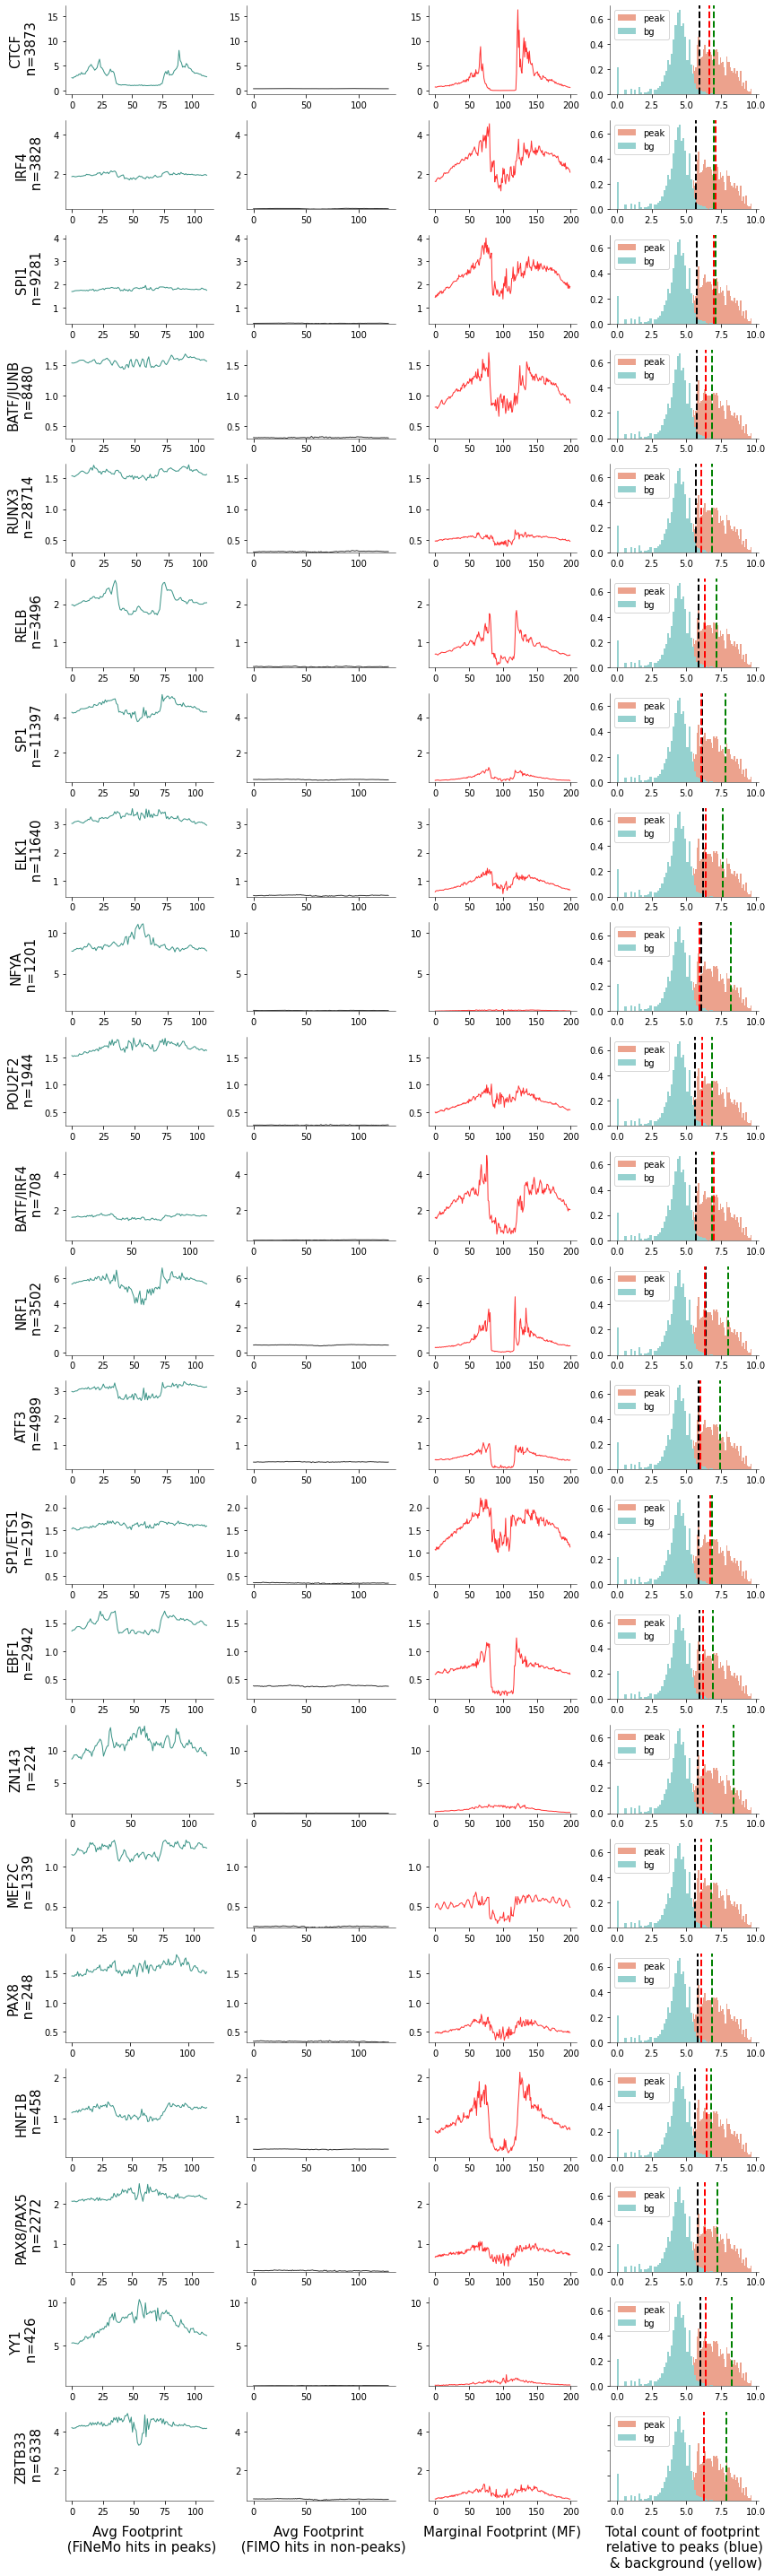

In [140]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib import rc
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('axes', linewidth=0.5) 

nrows=22
fig,axs = plt.subplots(nrows,4,figsize=(12,40))

models = ["Avg Footprint \n (FiNeMo hits in peaks)", "Avg Footprint \n (FIMO hits in non-peaks)", "Marginal Footprint (MF)", "Total count of footprint \n relative to peaks (blue) \n & background (yellow)"]
#ylims=[0.009,0.009, 0.009, 0.009, 0.009, 0.009, 0.009]
i=0
num_motfs=[]
for motif in motifs:
    print(motif)
    kmotif=motif.replace("GM12878_SIGNAL_metacluster_0_","")
    df = bound[bound[5]=="pos_patterns."+kmotif]
    num_motfs.append(df.shape[0])
    axs[i,0].plot(bound_footprints[kmotif][0], alpha=0.8, label="Bound", c="#097969",linewidth=1)
    axs[i,1].plot(unbound_footprints[kmotif][0], alpha=0.8, label="Unbound", c="black",linewidth=1)
    axs[i,2].plot(marginal_footprints[kmotif][400:600], alpha=0.8, label="Marginal", c="red",linewidth=1)
    plot_histogram(peak_counts_pred, nonpeak_counts_pred, np.log(marginal_footprints_counts[kmotif]), np.log(bound_footprints[kmotif][1]),  np.log(unbound_footprints[kmotif][1]), motifs_names[i], axs[i,3])
    i=i+1
    
    
ndx=0
for ax, col in zip(axs[:,0], motifs_names):
    #print(col)
    ax.set_ylabel(col+"\n n="+str(num_motfs[ndx]), rotation=90, labelpad=10, fontsize=15)
    ndx+=1

for ax, row in zip(axs[-1], models):
    ax.set_xlabel(row, rotation=0, labelpad=10, fontsize=15)

for i in range(nrows):
    ylim1 = axs[i, 0].get_ylim()
    ylim2 = axs[i, 2].get_ylim()
    ylim3 = axs[i, 1].get_ylim()
    for j in range(3):
        axs[i, j].set_ylim((min(ylim1[0], ylim2[0], ylim3[0]),max(ylim1[1], ylim2[1], ylim3[1])))
        axs[i,j].spines['top'].set_visible(False)
        axs[i,j].spines['right'].set_visible(False)
plt.yticks(visible=False)


fig.tight_layout()

plt.savefig("figures/motif_plots_all.pdf", transparent=True, dpi=300)


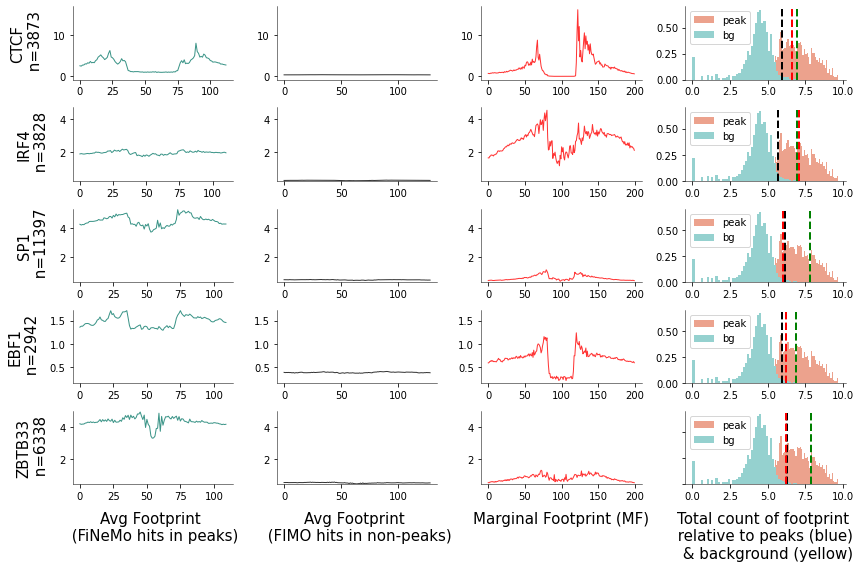

In [142]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib import rc
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('axes', linewidth=0.5) 

fig,axs = plt.subplots(5,4,figsize=(12,8))

models = ["Avg Footprint \n (FiNeMo hits in peaks)", "Avg Footprint \n (FIMO hits in non-peaks)", "Marginal Footprint (MF)", "Total count of footprint \n relative to peaks (blue) \n & background (yellow)"]
#ylims=[0.009,0.009, 0.009, 0.009, 0.009, 0.009, 0.009]
i=0
j=0
num_motfs=[]
for motif in motifs:
    #print(motifs_names[i])
    if motifs_names[i]  not in ["CTCF", "IRF4", "SP1", "EBF1", "ZBTB33"]:
        i=i+1
        continue
    #print(motif)
    
    kmotif=motif.replace("GM12878_SIGNAL_metacluster_0_","")
    df = bound[bound[5]=="pos_patterns."+kmotif]
    num_motfs.append(df.shape[0])
    axs[j,0].plot(bound_footprints[kmotif][0], alpha=0.8, label="Bound", c="#097969",linewidth=1)
    axs[j,1].plot(unbound_footprints[kmotif][0], alpha=0.8, label="Unbound", c="black",linewidth=1)
    axs[j,2].plot(marginal_footprints[kmotif][400:600], alpha=0.8, label="Marginal", c="red",linewidth=1)
    plot_histogram(peak_counts_pred, nonpeak_counts_pred, np.log(marginal_footprints_counts[kmotif]), np.log(bound_footprints[kmotif][1]),  np.log(unbound_footprints[kmotif][1]), motifs_names[i], axs[j,3])
    j=j+1
    i=i+1

    
ndx=0
for ax, col in zip(axs[:,0], ["CTCF", "IRF4", "SP1", "EBF1", "ZBTB33"]):
    ax.set_ylabel(col+"\n n="+str(num_motfs[ndx]), rotation=90, labelpad=10, fontsize=15)
    ndx+=1
for ax, row in zip(axs[-1], models):
    ax.set_xlabel(row, rotation=0, labelpad=10, fontsize=15)

for i in range(5):
    ylim1 = axs[i, 0].get_ylim()
    ylim2 = axs[i, 2].get_ylim()
    ylim3 = axs[i, 1].get_ylim()
    for j in range(3):
        axs[i, j].set_ylim((min(ylim1[0], ylim2[0], ylim3[0]),max(ylim1[1], ylim2[1], ylim3[1])))
        axs[i,j].spines['top'].set_visible(False)
        axs[i,j].spines['right'].set_visible(False)
        
plt.yticks(visible=False)


fig.tight_layout()

 

plt.savefig("figures/motif_plots_subset.pdf", transparent=True, dpi=300)
